In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
load_dotenv()

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [2]:
from typing import Annotated

from langchain_core.tools import tool
from langchain_community.tools import DuckDuckGoSearchResults
from langchain_community.utilities import DuckDuckGoSearchAPIWrapper
from typing_extensions import TypedDict

from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

@tool
def get_web_search(query: str, search_period: str='m') -> str:
    """
    웹 검색을 수행하는 함수.
    """
    wrapper = DuckDuckGoSearchAPIWrapper(
        time=search_period
    )

    print('\n-------- WEB SEARCH --------')
    print(query)
    print(search_period)

    search = DuckDuckGoSearchResults(
        api_wrapper=wrapper,
        results_separator=';\n'
    )

    searched = search.invoke(query)
    
    for i, result in enumerate(searched.split(';\n')):
        print(f'{i+1}. {result}')
    
    return searched

# 도구 바인딩
tools = [get_web_search]

llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

graph_builder.add_node("chatbot", chatbot)

tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

memory = InMemorySaver()
graph = graph_builder.compile(checkpointer=memory)

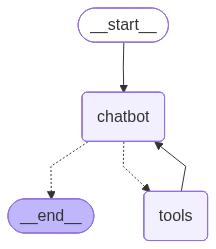

In [3]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [4]:
config = {"configurable": {"thread_id": "1"}}

events = graph.stream(
    {
        "messages": [
            {
                "role": "user",
                "content": (
                    "LangGraph를 배우는 중입니다. "
                    "LangGraph에 대해 조사를 좀 해주시겠어요?"
                ),
            },
        ],
    },
    config,
    stream_mode="values",
)
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

LangGraph를 배우는 중입니다. LangGraph에 대해 조사를 좀 해주시겠어요?
================================== Ai Message ==================================
Tool Calls:
  get_web_search (21c8aeb0-6dce-4699-91b8-168b3ed7d8ad)
 Call ID: 21c8aeb0-6dce-4699-91b8-168b3ed7d8ad
  Args:
    query: LangGraph

-------- WEB SEARCH --------
LangGraph
m
1. snippet: Designed for human-agent collaboration. With built-in statefulness, LangGraph agents seamlessly collaborate with humans by writing drafts for review and awaiting approval before acting., title: Build controllable agents with LangGraph , our low-level agent..., link: https://www.langchain.com/langgraph
2. snippet: LangGraph is an open-source framework by LangChain that lets you build AI agents as state machines (or graphs ). simply can say as it’s a framework for building stateful, multi-step..., title: LangGraph : Build Smart AI Agents with Ease | by Puli Hima... | Medium, link: http

In [5]:
to_replay = None
for state in graph.get_state_history(config):
    print("Num Messages: ", len(state.values["messages"]), "Next: ", state.next)
    print("-" * 80)
    if len(state.values["messages"]) == 2:
        # We are somewhat arbitrarily selecting a specific state based on the number of chat messages in the state.
        to_replay = state

Num Messages:  4 Next:  ()
--------------------------------------------------------------------------------
Num Messages:  3 Next:  ('chatbot',)
--------------------------------------------------------------------------------
Num Messages:  2 Next:  ('tools',)
--------------------------------------------------------------------------------
Num Messages:  1 Next:  ('chatbot',)
--------------------------------------------------------------------------------
Num Messages:  0 Next:  ('__start__',)
--------------------------------------------------------------------------------


In [6]:
print(to_replay.next)
print(to_replay.config)

('tools',)
{'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0d1dec-ba4e-6fd4-8001-d131b35c25e8'}}


In [7]:
# The `checkpoint_id` in the `to_replay.config` corresponds to a state we've persisted to our checkpointer.
for event in graph.stream(None, to_replay.config, stream_mode="values"):
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  get_web_search (21c8aeb0-6dce-4699-91b8-168b3ed7d8ad)
 Call ID: 21c8aeb0-6dce-4699-91b8-168b3ed7d8ad
  Args:
    query: LangGraph

-------- WEB SEARCH --------
LangGraph
m
1. snippet: Nov 25, 2025 · Trusted by companies shaping the future of agents – including Klarna, Replit, Elastic, and more – LangGraph is a low-level orchestration framework for building, managing, and deploying long-running, stateful agents., title: langgraph · PyPI, link: https://pypi.org/project/langgraph/
2. snippet: Nov 21, 2025 · In this guide, you’ll learn what LangGraph is, when to use it, how to model real multi‑agent patterns, and how to deploy distributed AI flows that are resilient, observable, and cost‑efficient., title: LangGraph in Practice: Orchestrating Multi‑Agent Systems and ..., link: https://bix-tech.com/langgraph-in-practice-orchestrating-multiagent-systems-and-distributed-ai-flows-at-scale/
3. snippet